In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

In [2]:
script_dir = os.getcwd() 
file_path = os.path.join(script_dir, "wdbc.data")

if not os.path.exists(file_path):
    print(f"Το αρχείο {file_path} δεν βρέθηκε!")
else:
    col_names = ['ID', 'Diagnosis']
    
    features_base = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
    
    for type_ in ['mean', 'se', 'worst']:
        for feat in features_base:
            col_names.append(f"{feat}_{type_}")

    df = pd.read_csv(file_path, header=None, names=col_names)
    
    print(f"Διαστάσεις: {df.shape}")
    print(df.head())

Διαστάσεις: (569, 32)
         ID Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  per

In [3]:
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])

constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
if constant_cols:
    df = df.drop(columns=constant_cols)
    print(f"Διαγράφηκαν σταθερές στήλες: {constant_cols}")
else:
    print("Δεν βρέθηκαν σταθερές στήλες.")

target_corr = df.corrwith(df['Diagnosis']).abs()

leakage_cols = target_corr[target_corr > 0.95].index.tolist()

if 'Diagnosis' in leakage_cols:
    leakage_cols.remove('Diagnosis')

if leakage_cols:
    print(f"Βρέθηκαν ύποπτες στήλες για Leakage: {leakage_cols}")
    print("Διαγράφονται για ασφάλεια.")
    df = df.drop(columns=leakage_cols)
else:
    print("Κανένα χαρακτηριστικό δεν φαίνεται να προδίδει την απάντηση.")

features = df.drop('Diagnosis', axis=1)
corr_matrix = features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_redundant = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Έλεγχος (Feature-Feature Correlation > 95%):")
print(f"Διαγραφή: {to_drop_redundant}")

df_reduced = df.drop(columns=to_drop_redundant)

Δεν βρέθηκαν σταθερές στήλες.
Κανένα χαρακτηριστικό δεν φαίνεται να προδίδει την απάντηση.
Έλεγχος (Feature-Feature Correlation > 95%):
Διαγραφή: ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']


In [4]:
duplicates = df_reduced.duplicated().sum()

if duplicates > 0:
    print(f"Βρέθηκαν {duplicates} διπλότυπες εγγραφές. Διαγράφονται...")
    df_reduced = df_reduced.drop_duplicates()
else:
    print("Δεν βρέθηκαν διπλότυπες εγγραφές.")

total_nulls = df_reduced.isnull().sum().sum()

if total_nulls > 0:
    print(f"Βρέθηκαν {total_nulls} κενές τιμές.")

    print("Διαγραφή γραμμών με κενά...")
    df_reduced = df_reduced.dropna()
else:
    print("Δεν βρέθηκαν κενές τιμές (Το dataset είναι πλήρες).")

print("Έλεγχος Outliers (Χωρίς Διαγραφή):")
print("Στρατηγική: Διατήρηση όλων των δεδομένων.")

Q1 = df_reduced.quantile(0.25)
Q3 = df_reduced.quantile(0.75)
IQR = Q3 - Q1
outliers_count = ((df_reduced < (Q1 - 1.5 * IQR)) | (df_reduced > (Q3 + 1.5 * IQR))).sum().sum()

print(f"Υπάρχουν {outliers_count} τιμές που θεωρούνται στατιστικά 'ακραίες'.")
print("Αυτές οι τιμές παραμένουν στο dataset γιατί μπορεί να υποδηλώνουν κακοήθεια.")

df_final = df_reduced.copy()

print(f"ΤΕΛΙΚΕΣ ΔΙΑΣΤΑΣΕΙΣ ΓΙΑ ΕΚΠΑΙΔΕΥΣΗ: {df_final.shape}")

Δεν βρέθηκαν διπλότυπες εγγραφές.
Δεν βρέθηκαν κενές τιμές (Το dataset είναι πλήρες).
Έλεγχος Outliers (Χωρίς Διαγραφή):
Στρατηγική: Διατήρηση όλων των δεδομένων.
Υπάρχουν 400 τιμές που θεωρούνται στατιστικά 'ακραίες'.
Αυτές οι τιμές παραμένουν στο dataset γιατί μπορεί να υποδηλώνουν κακοήθεια.
ΤΕΛΙΚΕΣ ΔΙΑΣΤΑΣΕΙΣ ΓΙΑ ΕΚΠΑΙΔΕΥΣΗ: (569, 24)


In [5]:
X = df_final.drop('Diagnosis', axis=1)
y = df_final['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Διαχωρισμός ολοκληρώθηκε.")
print(f"   -> Train set: {X_train.shape}")
print(f"   -> Test set:  {X_test.shape}")

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Δείγμα από τα scaled δεδομένα:")
print(X_train_df.head())

Διαχωρισμός ολοκληρώθηκε.
   -> Train set: (455, 23)
   -> Test set:  (114, 23)
Δείγμα από τα scaled δεδομένα:
   radius_mean  texture_mean  smoothness_mean  compactness_mean  \
0     0.634320      0.789809        -0.666667         -0.384148   
1    -0.241420     -1.184713         0.382398         -0.337311   
2    -0.115976      0.449500        -0.997977         -0.136906   
3     0.369231      0.660601         0.213961          1.954815   
4     1.247337      0.245678        -0.042489          0.214967   

   concavity_mean  concave_points_mean  symmetry_mean  fractal_dimension_mean  \
0       -0.257207            -0.002022      -0.812594               -0.495707   
1       -0.190203             0.067292       0.479760               -0.200343   
2        0.018115            -0.269719      -0.656672               -0.018317   
3        2.083171             1.172458       0.725637                0.879222   
4        0.872614             0.808421      -0.305847               -0.493417   


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_params = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],        # Πόσο "αυστηρό" είναι το μοντέλο
            'penalty': ['l1', 'l2'],             # Τρόπος τιμωρίας πολυπλοκότητας
            'solver': ['liblinear'],             # Αλγόριθμος επίλυσης (το liblinear είναι καλό για μικρά dataset)
            'class_weight': [None, 'balanced']   # Χειρισμός ανισορροπίας κλάσεων
        }
    },
    
    'SVM': {
        'model': SVC(probability=True, random_state=42), # probability=True για να έχουμε ROC curves
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],          # Περιθώριο σφάλματος
            'kernel': ['linear', 'rbf', 'poly'],   # Το σχήμα του διαχωρισμού (Ευθεία; Καμπύλη;)
            'gamma': ['scale', 'auto', 0.1, 0.01], # Πόσο μακριά φτάνει η επιρροή κάθε σημείου
            'degree': [2, 3]                       # Μόνο για το 'poly' kernel
        }
    },
    
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11],                   # Πόσους γείτονες ρωτάμε
            'weights': ['uniform', 'distance'],                # Μετράει η απόσταση ή μόνο η ψήφος;
            'metric': ['euclidean', 'manhattan', 'minkowski'], # Πώς μετράμε την απόσταση
            'p': [1, 2]                                        # Δύναμη για Minkowski (1=Manhattan, 2=Euclidean)
        }
    },
    
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200, 300], # Πόσα δέντρα θα φτιάξουμε
            'criterion': ['gini', 'entropy'],    # Πώς μετράμε την ποιότητα του διαχωρισμού
            'max_depth': [None, 10, 20, 30],     # Πόσο βαθιά πάνε οι ρίζες (αποφυγή overfitting)
            'min_samples_split': [2, 5, 10],     # Ελάχιστα δείγματα για να χωριστεί ένας κόμβος
            'bootstrap': [True, False]           # Να χρησιμοποιούμε δείγματα με επανατοποθέτηση;
        }
    },
    
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],          # Αριθμός βημάτων
            'learning_rate': [0.01, 0.05, 0.1, 0.2], # Πόσο γρήγορα μαθαίνει (μικρό = πιο αργό αλλά ακριβές)
            'max_depth': [3, 5, 7],                  # Βάθος δέντρου
            'subsample': [0.8, 1.0],                 # Ποσοστό δειγμάτων ανά δέντρο
            'colsample_bytree': [0.8, 1.0],          # Ποσοστό χαρακτηριστικών ανά δέντρο
            'gamma': [0, 0.1, 0.2]                   # Ελάχιστη μείωση απώλειας για split
        }
    }
}

results = []
best_estimators = {}

for name, config in models_params.items():
    
    grid = GridSearchCV(estimator=config['model'], 
                        param_grid=config['params'], 
                        cv=cv, 
                        scoring='f1',
                        n_jobs=-1, 
                        verbose=1)
    
    grid.fit(X_train_scaled, y_train)
    
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1] 
    
    res = {
        'Model': name,
        'Best Params': str(grid.best_params_), 
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }
    
    results.append(res)
    print(f"Best F1-Score: {res['F1-Score']:.4f}")
    print(f"Best Params: {grid.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best F1-Score: 0.9639
Best Params: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best F1-Score: 0.9630
Best Params: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best F1-Score: 0.9000
Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best F1-Score: 0.9512
Best Params: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best F1-Score: 0.9639
Best Params: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


ΤΕΛΙΚΗ ΚΑΤΑΤΑΞΗ ΜΟΝΤΕΛΩΝ (Βάσει F1-Score):
              Model  Accuracy   Recall  F1-Score  ROC AUC
Logistic Regression  0.973684 0.952381  0.963855 0.995370
            XGBoost  0.973684 0.952381  0.963855 0.987765
                SVM  0.973684 0.928571  0.962963 0.992063
      Random Forest  0.964912 0.928571  0.951220 0.991567
                KNN  0.929825 0.857143  0.900000 0.989749
Τα αποτελέσματα αποθηκεύτηκαν στο 'final_model_results.csv'


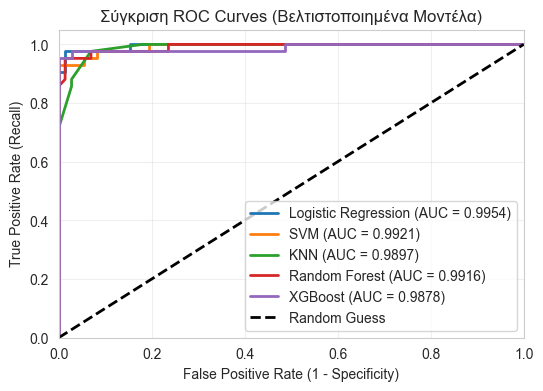

In [7]:
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)

print("ΤΕΛΙΚΗ ΚΑΤΑΤΑΞΗ ΜΟΝΤΕΛΩΝ (Βάσει F1-Score):")
print(results_df[['Model', 'Accuracy', 'Recall', 'F1-Score', 'ROC AUC']].to_string(index=False))

results_df.to_csv('final_model_results.csv', index=False)
print("Τα αποτελέσματα αποθηκεύτηκαν στο 'final_model_results.csv'")

plt.figure(figsize=(6, 4))

for name, model in best_estimators.items():
    
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Σύγκριση ROC Curves (Βελτιστοποιημένα Μοντέλα)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

Best F1: 0.9639


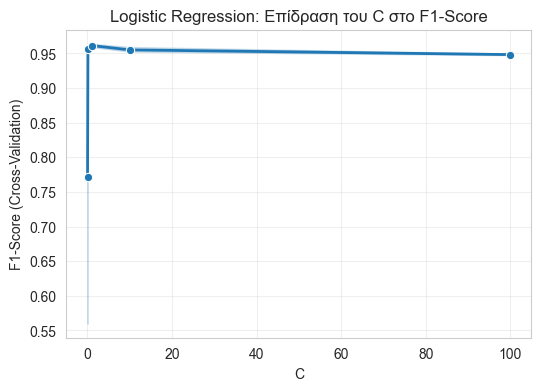

Best F1: 0.9630


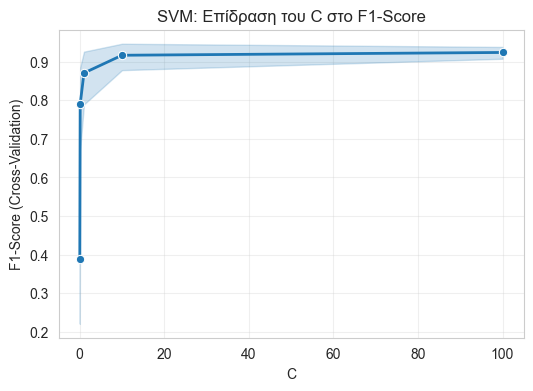

Best F1: 0.9000


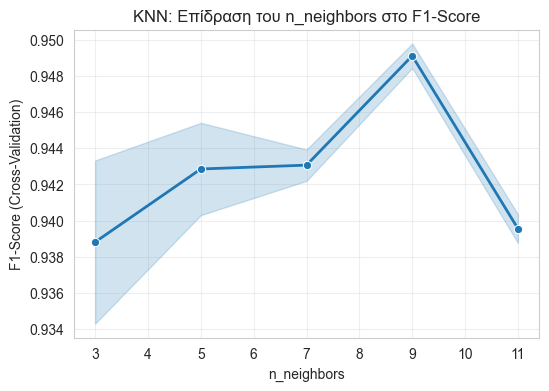

Best F1: 0.9512


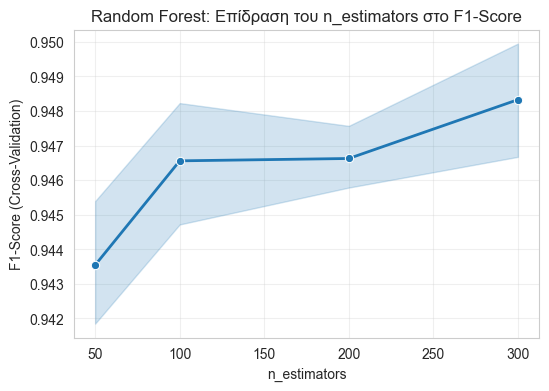

Best F1: 0.9639


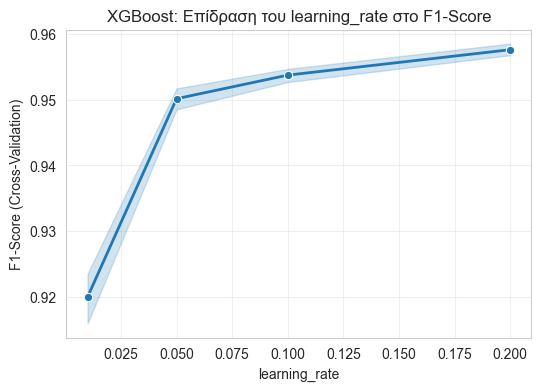

In [8]:
param_to_plot = {
    'Logistic Regression': 'param_C',
    'SVM': 'param_C',
    'KNN': 'param_n_neighbors',
    'Random Forest': 'param_n_estimators',
    'XGBoost': 'param_learning_rate'
}

results = []
best_estimators = {}

for name, config in models_params.items():
    
    grid = GridSearchCV(estimator=config['model'], 
                        param_grid=config['params'], 
                        cv=cv, 
                        scoring='f1', 
                        n_jobs=-1)
    
    grid.fit(X_train_scaled, y_train)
    
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1] 
    
    res = {
        'Model': name,
        'Best Params': str(grid.best_params_), 
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }
    results.append(res)
    print(f"Best F1: {res['F1-Score']:.4f}")

    cv_results = pd.DataFrame(grid.cv_results_)
    
    param_col = param_to_plot.get(name)
    
    if param_col in cv_results.columns:
        plt.figure(figsize=(6, 4))
        
        # Ομαδοποιούμε βάσει της παραμέτρου και παίρνουμε τον μέσο όρο του score
        # (Αυτό χρειάζεται επειδή το GridSearch αλλάζει και άλλες παραμέτρους ταυτόχρονα)
        sns.lineplot(data=cv_results, x=param_col, y='mean_test_score', marker='o', linewidth=2)
        
        plt.title(f'{name}: Επίδραση του {param_col.replace("param_", "")} στο F1-Score')
        plt.xlabel(param_col.replace("param_", ""))
        plt.ylabel('F1-Score (Cross-Validation)')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"Δεν βρέθηκε η παράμετρος {param_col} για σχεδίαση.")